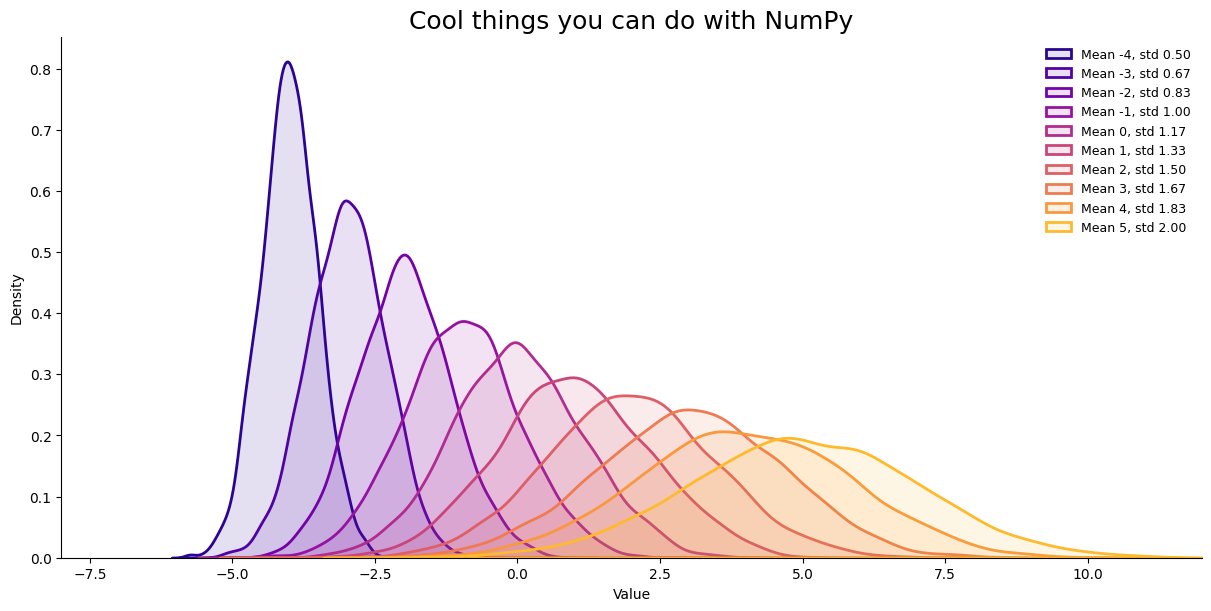

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

demo_rng = np.random.default_rng(42)
means = np.linspace(-4, 5, 10)
standard_deviations = np.linspace(0.5, 2, 10)
samples = demo_rng.normal(loc=means, scale=standard_deviations, size=(5_000, 10))

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
colours = plt.cm.plasma(np.linspace(0.05, 0.85, 10))

for i in range(10):
    sns.kdeplot(
        x=samples[:, i], fill=True, alpha=0.12, linewidth=2,
        color=colours[i], label=f"Mean {means[i]:.0f}, std {standard_deviations[i]:.2f}", ax=ax,
    )

ax.set(title="Cool things you can do with NumPy", xlabel="Value", ylabel="Density", xlim=(-8, 12))
ax.title.set_fontsize(18)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

# NumPy & plotting
Lists → arrays → vectorization → broadcasting → plots

Run cells from top to bottom. Stop at **Try it** to practise.


In [19]:
# Run once if these packages are missing, then restart the kernel.
# %pip install numpy matplotlib "seaborn>=0.13.2"


## Part 1 · NumPy
### 1. Start with a list


In [20]:
temperatures = [18, 21, 19, 25, 23]
print(temperatures)
print(type(temperatures))
print("Length:", len(temperatures))
print("Total:", sum(temperatures))
print("Average:", sum(temperatures) / len(temperatures))


[18, 21, 19, 25, 23]
<class 'list'>
Length: 5
Total: 106
Average: 21.2


**Indexing:** positions start at 0. **Slicing:** the stop position is excluded.


In [21]:
print("First:", temperatures[0])
print("Last:", temperatures[-1])
print("Positions 1 to 3:", temperatures[1:4])
print("Every second value:", temperatures[::2])
print("Reversed:", temperatures[::-1])


First: 18
Last: 23
Positions 1 to 3: [21, 19, 25]
Every second value: [18, 19, 23]
Reversed: [23, 25, 19, 21, 18]


In [22]:
values = temperatures.copy()
values[0] = 20           # update
values.append(27)        # add one item
values.extend([22, 24])  # add several items
values.insert(1, 17)     # insert at a position
print("After adding:", values)

values.remove(17)        # remove the first matching value
last_value = values.pop()  # remove and return the last item
print("Popped:", last_value)
print("Remaining:", values)
print("Sorted copy:", sorted(values))


After adding: [20, 17, 21, 19, 25, 23, 27, 22, 24]
Popped: 24
Remaining: [20, 21, 19, 25, 23, 27, 22]
Sorted copy: [19, 20, 21, 22, 23, 25, 27]


### 2. What does arithmetic do to a list?
Predict the output first.


In [23]:
print([1, 2, 3] + [4, 5, 6])
print([1, 2, 3] * 2)


[1, 2, 3, 4, 5, 6]
[1, 2, 3, 1, 2, 3]


Convert Celsius to Fahrenheit: `F = C × 1.8 + 32`.


In [24]:
fahrenheit = []
for temperature in temperatures:
    fahrenheit.append(temperature * 1.8 + 32)
print(fahrenheit)

# Same calculation with a list comprehension
fahrenheit = [temperature * 1.8 + 32 for temperature in temperatures]
print(fahrenheit)


[64.4, 69.80000000000001, 66.2, 77.0, 73.4]
[64.4, 69.80000000000001, 66.2, 77.0, 73.4]


### 3. Meet the ndarray
A numeric array stores values with one dtype and supports elementwise arithmetic.


In [25]:
import numpy as np

celsius = np.array(temperatures, dtype=np.float64)
print(type(celsius))
print(celsius)
print(celsius * 1.8 + 32)
print(np.array([1, 2, 3]) + np.array([4, 5, 6]))
print(np.array([1, 2, 3]) * 2)


<class 'numpy.ndarray'>
[18. 21. 19. 25. 23.]
[64.4 69.8 66.2 77.  73.4]
[5 7 9]
[2 4 6]


### 4. How much faster?
Same formula, same values. Time repeated runs; keep input creation outside the calculation.


In [26]:
from timeit import repeat
from statistics import median

def convert_list(values):
    return [value * 1.8 + 32 for value in values]

def convert_array(values):
    return values * 1.8 + 32

def milliseconds_per_call(function, number):
    function()  # warm-up
    timings = repeat(function, repeat=5, number=number)
    return median(timings) / number * 1_000

benchmark_results = []
for size, calls in [(10, 1000), (1_000, 100), (1_000_000, 3)]:
    array_input = np.linspace(0, 40, size)
    list_input = array_input.tolist()
    np.testing.assert_allclose(convert_list(list_input), convert_array(array_input))

    list_ms = milliseconds_per_call(lambda: convert_list(list_input), calls)
    array_ms = milliseconds_per_call(lambda: convert_array(array_input), calls)
    with_conversion_ms = milliseconds_per_call(
        lambda: convert_array(np.asarray(list_input, dtype=np.float64)), calls
    )
    benchmark_results.append((size, list_ms, array_ms, with_conversion_ms))

print(f"{'Items':>10} {'List (ms)':>12} {'Array (ms)':>12} {'Convert + array (ms)':>22} {'List/array':>12}")
for size, list_ms, array_ms, conversion_ms in benchmark_results:
    print(f"{size:>10,} {list_ms:>12.5f} {array_ms:>12.5f} {conversion_ms:>22.5f} {list_ms / array_ms:>11.2f}x")


     Items    List (ms)   Array (ms)   Convert + array (ms)   List/array
        10      0.00038      0.00084                0.00121        0.46x
     1,000      0.02666      0.00121                0.01816       22.11x
 1,000,000     33.47601      0.91469               19.82842       36.60x


**Vectorization:** write an operation on a whole array; NumPy runs the numeric loops in compiled code.

Small inputs and list-to-array conversion can reduce the benefit. Timings depend on your machine.


### 5. Create and inspect arrays


In [27]:
print("Zeros:", np.zeros(4))
print("Ones:\n", np.ones((2, 3)))
print("Filled:", np.full(4, 7))
print("Step of 2:", np.arange(0, 10, 2))
print("Five evenly spaced points:", np.linspace(0, 1, 5))


Zeros: [0. 0. 0. 0.]
Ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
Filled: [7 7 7 7]
Step of 2: [0 2 4 6 8]
Five evenly spaced points: [0.   0.25 0.5  0.75 1.  ]


In [28]:
# Rows = students; columns = Maths, Science, English
subjects = ["Maths", "Science", "English"]
students = ["Asha", "Ben", "Chen", "Diya"]
marks = np.array([
    [72, 81, 68],
    [90, 85, 88],
    [65, 70, 75],
    [84, 79, 92],
])

print(marks)
print("Shape:", marks.shape)
print("Dimensions:", marks.ndim)
print("Elements:", marks.size)
print("Data type:", marks.dtype)
print("Element storage (bytes):", marks.nbytes)


[[72 81 68]
 [90 85 88]
 [65 70 75]
 [84 79 92]]
Shape: (4, 3)
Dimensions: 2
Elements: 12
Data type: int64
Element storage (bytes): 96


**dtype matters:** integer arrays cannot preserve fractional values when you assign into them.


In [29]:
whole_numbers = np.array([1, 2, 3], dtype=np.int64)
whole_numbers[0] = 1.9
print("Integer storage:", whole_numbers)

decimal_numbers = np.array([1, 2, 3], dtype=np.float64)
decimal_numbers[0] = 1.9
print("Float storage:", decimal_numbers)


Integer storage: [1 2 3]
Float storage: [1.9 2.  3. ]


### 6. Index, slice, filter
For 2D arrays: `array[row, column]`.


In [30]:
print("Ben's Science mark:", marks[1, 1])
print("First student:", marks[0, :])
print("All Science marks:", marks[:, 1])
print("First two students, first two subjects:\n", marks[:2, :2])
print("Selected students:\n", marks[[0, 3]])


Ben's Science mark: 85
First student: [72 81 68]
All Science marks: [81 85 70 79]
First two students, first two subjects:
 [[72 81]
 [90 85]]
Selected students:
 [[72 81 68]
 [84 79 92]]


Put a condition inside `[]` to keep matching values. Combine conditions with `&` (and) or `|` (or), using parentheses.

In [31]:
numbers = np.array([5, 12, 18, 24, 31, 42])

print("Above 20:", numbers[numbers > 20])
print("Even numbers:", numbers[numbers % 2 == 0])
print("Between 10 and 30:", numbers[(numbers >= 10) & (numbers <= 30)])
print("Below 10 or above 30:", numbers[(numbers < 10) | (numbers > 30)])

Above 20: [24 31 42]
Even numbers: [12 18 24 42]
Between 10 and 30: [12 18 24]
Below 10 or above 30: [ 5 31 42]


In [32]:
high_marks = marks >= 80
print("Mask:\n", high_marks)
print("Matching values:", marks[high_marks])
print("Students with Maths >= 80:\n", marks[marks[:, 0] >= 80])
print("Marks from 70 to 85:", marks[(marks >= 70) & (marks <= 85)])


Mask:
 [[False  True False]
 [ True  True  True]
 [False False False]
 [ True False  True]]
Matching values: [81 90 85 88 84 92]
Students with Maths >= 80:
 [[90 85 88]
 [84 79 92]]
Marks from 70 to 85: [72 81 85 70 75 84 79]


### 7. Array operations and axes
`axis=0` reduces across students; `axis=1` reduces across subjects.


In [33]:
print("Overall mean:", marks.mean())
print("Mean per subject:", marks.mean(axis=0))
print("Mean per student:", marks.mean(axis=1))
print("Best mark per subject:", marks.max(axis=0))
print("Student with best Maths mark:", students[marks[:, 0].argmax()])


Overall mean: 79.08333333333333
Mean per subject: [77.75 78.75 80.75]
Mean per student: [73.66666667 87.66666667 70.         85.        ]
Best mark per subject: [90 85 92]
Student with best Maths mark: Ben


In [34]:
print("Square roots:", np.sqrt([1, 4, 9, 16]))
print("Squared marks:\n", np.square(marks))
print("Add 10, cap at 100:\n", np.clip(marks + 10, 0, 100))
print("Labels:\n", np.where(marks >= 80, "80 or above", "Below 80"))


Square roots: [1. 2. 3. 4.]
Squared marks:
 [[5184 6561 4624]
 [8100 7225 7744]
 [4225 4900 5625]
 [7056 6241 8464]]
Add 10, cap at 100:
 [[ 82  91  78]
 [100  95  98]
 [ 75  80  85]
 [ 94  89 100]]
Labels:
 [['Below 80' '80 or above' 'Below 80']
 ['80 or above' '80 or above' '80 or above']
 ['Below 80' 'Below 80' 'Below 80']
 ['80 or above' 'Below 80' '80 or above']]


### Try it · arrays
Find each student’s total. Select students whose average is at least 80.


In [35]:
# Your code here


### 8. Reshape, transpose, combine


In [36]:
sequence = np.arange(12)
grid = sequence.reshape(3, 4)  # same number of elements
print("3 × 4:\n", grid)
print("Transpose:\n", grid.T)
print("Flattened:", grid.ravel())
print("Infer the rows:\n", sequence.reshape(-1, 2))


3 × 4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Transpose:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Infer the rows:
 [[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]]


In [37]:
new_student = np.array([[78, 82, 80]])
print("Add a row:\n", np.concatenate([marks, new_student], axis=0))

project_marks = np.array([85, 91, 77, 88])
print("Add a column:\n", np.column_stack([marks, project_marks]))


Add a row:
 [[72 81 68]
 [90 85 88]
 [65 70 75]
 [84 79 92]
 [78 82 80]]
Add a column:
 [[72 81 68 85]
 [90 85 88 91]
 [65 70 75 77]
 [84 79 92 88]]


### 9. Broadcasting: why do we need it?
Add a different bonus to each subject, for every student.


In [38]:
subject_bonus = np.array([5, 2, 0])
print("Marks shape:", marks.shape)
print("Bonus shape:", subject_bonus.shape)
print("Adjusted marks:\n", marks + subject_bonus)


Marks shape: (4, 3)
Bonus shape: (3,)
Adjusted marks:
 [[77 83 68]
 [95 87 88]
 [70 72 75]
 [89 81 92]]


Compare shapes **from the right**. Dimensions must match, or one must be `1`. Missing dimensions count as `1`.

`(4, 3) + (3,) → (4, 3)`

Broadcasting reuses values without building a repeated input array.


What if each **student** gets a different bonus?


In [39]:
student_bonus = np.array([1, 2, 3, 4])

try:
    marks + student_bonus  # (4, 3) + (4,) cannot broadcast
except ValueError as error:
    print(error)

bonus_column = student_bonus[:, np.newaxis]  # (4,) -> (4, 1)
print("Bonus column:\n", bonus_column)
print("Adjusted marks:\n", marks + bonus_column)


operands could not be broadcast together with shapes (4,3) (4,) 
Bonus column:
 [[1]
 [2]
 [3]
 [4]]
Adjusted marks:
 [[73 82 69]
 [92 87 90]
 [68 73 78]
 [88 83 96]]


A practical use: centre each subject around its own mean.


In [40]:
subject_means = marks.mean(axis=0, keepdims=True)
centred_marks = marks - subject_means
print("Mean shape:", subject_means.shape)
print("Centred marks:\n", centred_marks)
print("New subject means:", centred_marks.mean(axis=0))


Mean shape: (1, 3)
Centred marks:
 [[ -5.75   2.25 -12.75]
 [ 12.25   6.25   7.25]
 [-12.75  -8.75  -5.75]
 [  6.25   0.25  11.25]]
New subject means: [0. 0. 0.]


### Try it · broadcasting
Subtract each student’s own average from their marks. Use `keepdims=True`.


In [41]:
# Your code here


### 10. Copies and views
A basic slice usually shares data with the original. Use `.copy()` for independent data.


In [42]:
original = np.array([10, 20, 30, 40])
view = original[1:3]
view[0] = 999
print("Original after editing a slice:", original)

independent = original[1:3].copy()
independent[0] = -1
print("Original after editing a copy:", original)

selected = original[[0, 2]]  # advanced indexing returns a copy
selected[0] = -100
print("Original after editing a selection:", original)


Original after editing a slice: [ 10 999  30  40]
Original after editing a copy: [ 10 999  30  40]
Original after editing a selection: [ 10 999  30  40]


### 11. Random data and missing values


In [43]:
rng = np.random.default_rng(42)
print("Dice:", rng.integers(1, 7, size=10))
print("Normal samples:", rng.normal(loc=0, scale=1, size=5))

readings = np.array([20.0, 21.5, np.nan, 19.0])
print("Missing:", np.isnan(readings))
print("Mean:", readings.mean())
print("Mean of available readings:", np.nanmean(readings))


Dice: [1 5 4 3 3 6 1 5 2 1]
Normal samples: [-1.30217951  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Missing: [False False  True False]
Mean: nan
Mean of available readings: 20.166666666666668


### 12. Going further · matrix operations (optional)
`*` multiplies element by element. `@` performs matrix multiplication.


In [44]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[2, 0], [1, 2]])
print("Elementwise:\n", a * b)
print("Matrix product:\n", a @ b)

weights = np.array([0.4, 0.35, 0.25])
print("Weighted score per student:", marks @ weights)


Elementwise:
 [[2 0]
 [3 8]]
Matrix product:
 [[ 4  4]
 [10  8]]
Weighted score per student: [74.15 87.75 69.25 84.25]


In [45]:
# Solve: 2x + y = 5, x - y = 1
coefficients = np.array([[2.0, 1.0], [1.0, -1.0]])
totals = np.array([5.0, 1.0])
solution = np.linalg.solve(coefficients, totals)
print("x, y:", solution)
print("Check:", np.allclose(coefficients @ solution, totals))


x, y: [2. 1.]
Check: True


### 13. Going further · pairwise distances (optional)
Broadcast point pairs, then calculate Euclidean distance. The output grows as `N × N`.


In [46]:
points = np.array([[0., 0.], [3., 4.], [6., 0.]])
differences = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distances = np.sqrt(np.sum(differences ** 2, axis=-1))
print("Pair differences shape:", differences.shape)
print("Distances:\n", distances)


Pair differences shape: (3, 3, 2)
Distances:
 [[0. 5. 6.]
 [5. 0. 5.]
 [6. 5. 0.]]


### 14. What can NumPy do on its own?


| NumPy alone | Reach for another library |
|---|---|
| Numeric arrays, filtering, statistics | pandas: labelled tables, joins, mixed columns |
| Matrix algebra, random simulation, FFT | SciPy: optimisation, integration, sparse algorithms |
| Array calculations for images and signals | Pillow / scikit-image: image files and image tools |
| `.npy` files and simple numeric text files | Matplotlib / Seaborn: plotting |
| Building blocks for numerical models | scikit-learn: model training and evaluation |

Lists still suit mixed objects and frequent appends. Numeric arrays suit bulk calculations.


In [47]:
from pathlib import Path

output_dir = Path("session_outputs")
output_dir.mkdir(exist_ok=True)
np.save(output_dir / "marks.npy", marks)
loaded_marks = np.load(output_dir / "marks.npy")
print("Round trip:", np.array_equal(marks, loaded_marks))


Round trip: True


## Part 2 · Plotting
### 15. What is a plot?
A plot maps data values to visual positions, lengths or colours. A library draws those marks on a figure.


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


### 16. Start with an empty plot
**Figure** = the whole canvas. **Axes** = one plotting area. Each Axes has an x-axis and a y-axis.


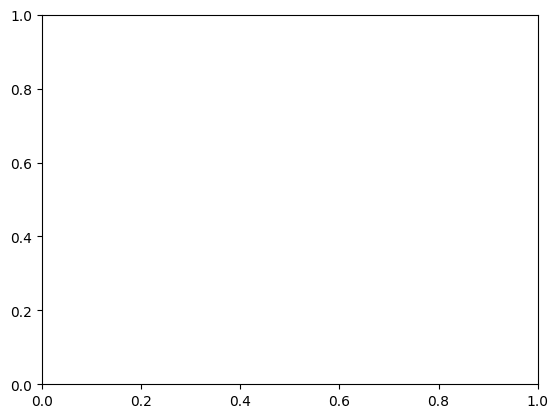

In [49]:
fig, ax = plt.subplots()
plt.show()


Now name the parts. `figsize=(width, height)` is measured in inches.


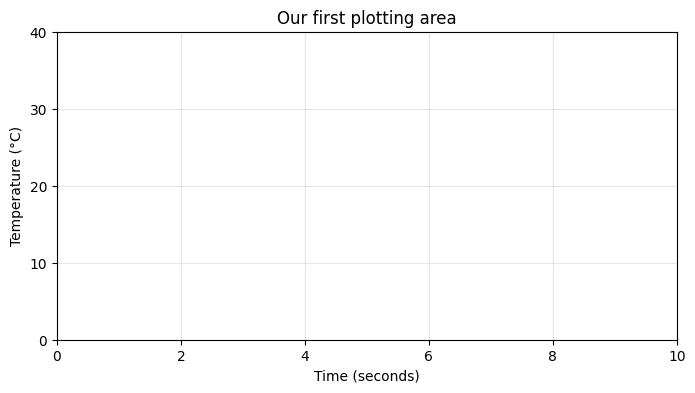

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title("Our first plotting area")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 40)
ax.set_xticks([0, 2, 4, 6, 8, 10])
ax.set_yticks([0, 10, 20, 30, 40])
ax.grid(alpha=0.3)
plt.show()


### 17. Add data: line, markers, legend
Lines show a trend along an ordered x-axis. The borders of the Axes are called **spines**.


In [51]:
import numpy as np

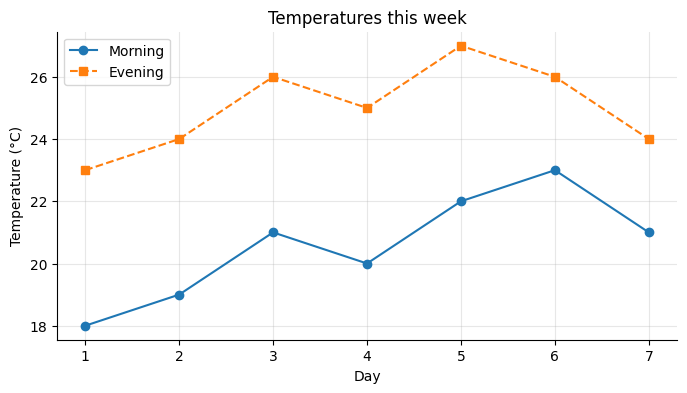

In [52]:
days = np.arange(1, 8)
morning = np.array([18, 19, 21, 20, 22, 23, 21])
evening = np.array([23, 24, 26, 25, 27, 26, 24])


## only for single plots and no subplots 
# plt.plot(days, morning, marker='o', label='morning')
# plt.xlabel("days")
# plt.ylabel("temperature")
# plt.title("temperature data")
# plt.legend()
# plt.grid(False)

## subplots
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, morning, marker="o", color="tab:blue", label="Morning")
ax.plot(days, evening, marker="s", linestyle="--", color="tab:orange", label="Evening")
ax.set(title="Temperatures this week", xlabel="Day", ylabel="Temperature (°C)")
ax.set_xticks(days)
ax.legend()
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


### 18. Scatter: how do two measurements relate?
Synthetic data for the next examples; no downloads needed.


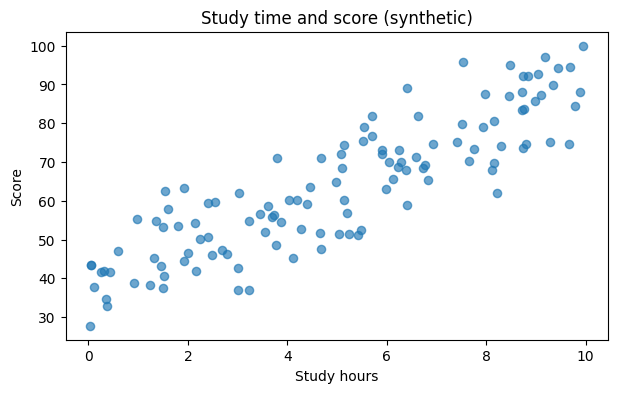

In [53]:
rng = np.random.default_rng(7)
study_hours = rng.uniform(0, 10, 120)
scores = np.clip(40 + 5 * study_hours + rng.normal(0, 9, 120), 0, 100)
groups = np.where(np.arange(120) % 2 == 0, "Group A", "Group B")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(study_hours, scores, alpha=0.65, s=35)
ax.set(title="Study time and score (synthetic)", xlabel="Study hours", ylabel="Score")
plt.show()


### 19. Bar: compare categories
A bar represents a category; a histogram bin represents a numeric interval.


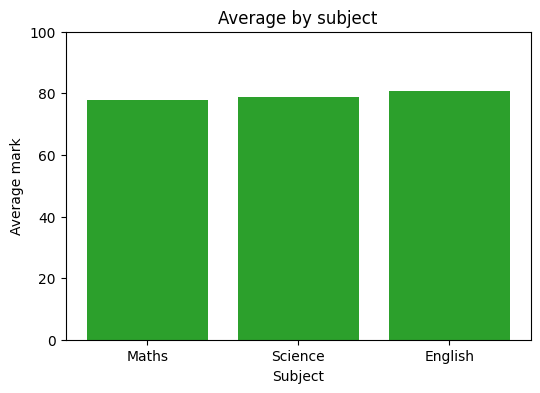

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(subjects, marks.mean(axis=0), color="tab:green")
ax.set(title="Average by subject", xlabel="Subject", ylabel="Average mark", ylim=(0, 100))
plt.show()


### 20. Histogram: how are values distributed?
Change `bins` and compare the result.


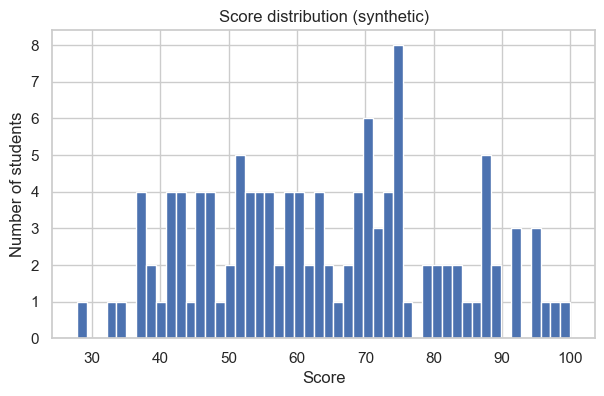

In [70]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores, bins=50, edgecolor="white")
ax.set(title="Score distribution (synthetic)", xlabel="Score", ylabel="Number of students")
plt.show()


### 21. Subplots: several Axes in one Figure
`axes[row, column]` chooses a panel. Shared axes help compare the same quantities.


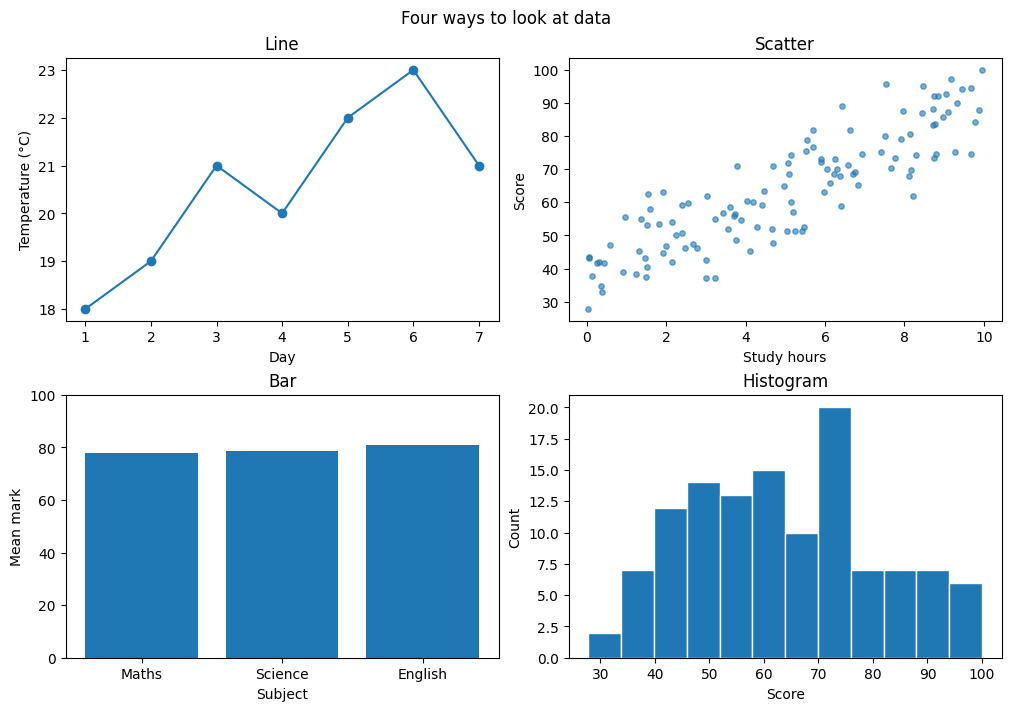

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), layout="constrained")

axes[0, 0].plot(days, morning, marker="o")
axes[0, 0].set(title="Line", xlabel="Day", ylabel="Temperature (°C)")

axes[0, 1].scatter(study_hours, scores, s=15, alpha=0.6)
axes[0, 1].set(title="Scatter", xlabel="Study hours", ylabel="Score")

axes[1, 0].bar(subjects, marks.mean(axis=0))
axes[1, 0].set(title="Bar", xlabel="Subject", ylabel="Mean mark", ylim=(0, 100))

axes[1, 1].hist(scores, bins=12, edgecolor="white")
axes[1, 1].set(title="Histogram", xlabel="Score", ylabel="Count")

fig.suptitle("Four ways to look at data")
plt.show()


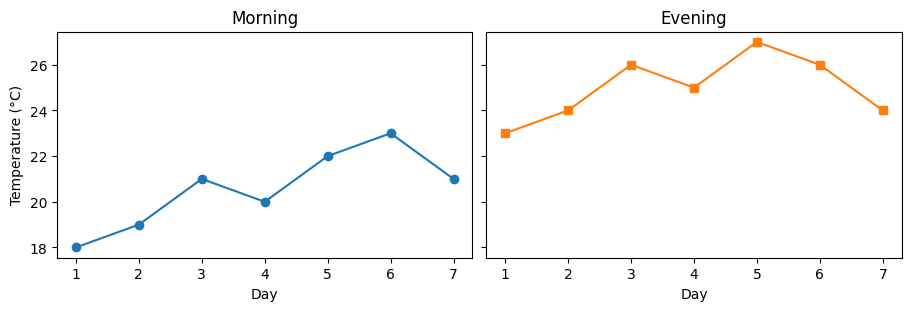

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharex=True, sharey=True, layout="constrained")
axes[0].plot(days, morning, marker="o")
axes[0].set(title="Morning", xlabel="Day", ylabel="Temperature (°C)")
axes[1].plot(days, evening, marker="s", color="tab:orange")
axes[1].set(title="Evening", xlabel="Day")
plt.show()


### Try it · plotting
Make two side-by-side plots: a line of evening temperatures and a histogram of scores. Add titles and axis labels.


In [58]:
# Your code here


### 22. Plot the timing results
Log scales make very different sizes and runtimes easier to compare.


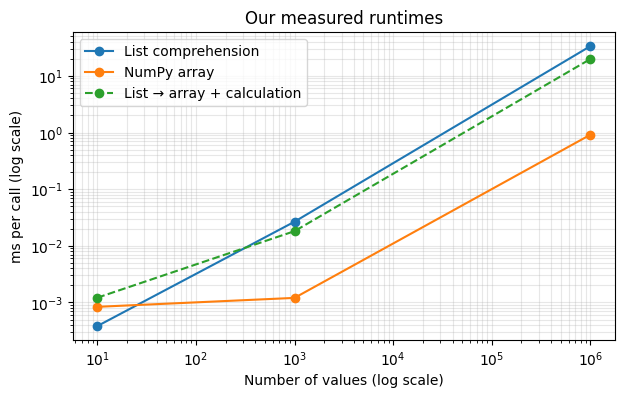

In [59]:
timing_array = np.array(benchmark_results)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(timing_array[:, 0], timing_array[:, 1], "o-", label="List comprehension")
ax.plot(timing_array[:, 0], timing_array[:, 2], "o-", label="NumPy array")
ax.plot(timing_array[:, 0], timing_array[:, 3], "o--", label="List → array + calculation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(title="Our measured runtimes", xlabel="Number of values (log scale)", ylabel="ms per call (log scale)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()


### 23. Matplotlib and Seaborn
Matplotlib gives detailed control over figures and plot elements. Seaborn builds on Matplotlib with convenient statistical plots and grouping.

Use Seaborn to draw, then use Matplotlib’s `ax` to customise.


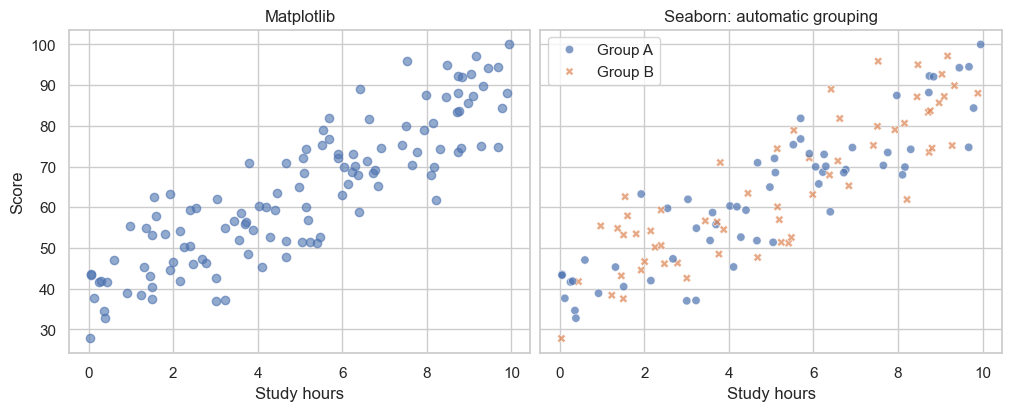

In [60]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True, layout="constrained")
axes[0].scatter(study_hours, scores, alpha=0.6)
axes[0].set(title="Matplotlib", xlabel="Study hours", ylabel="Score")

sns.scatterplot(x=study_hours, y=scores, hue=groups, style=groups, alpha=0.7, ax=axes[1])
axes[1].set(title="Seaborn: automatic grouping", xlabel="Study hours", ylabel="Score")
plt.show()


### 24. Distribution plots
A box shows the median and middle 50%; a violin adds a smoothed density estimate.


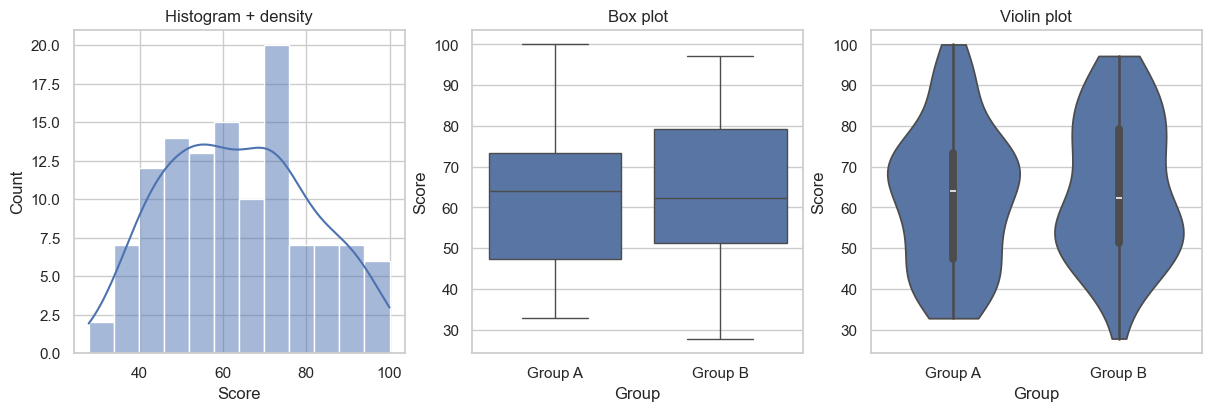

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")

sns.histplot(x=scores, bins=12, kde=True, ax=axes[0])
axes[0].set(title="Histogram + density", xlabel="Score", ylabel="Count")

sns.boxplot(x=groups, y=scores, ax=axes[1])
axes[1].set(title="Box plot", xlabel="Group", ylabel="Score")

sns.violinplot(x=groups, y=scores, cut=0, ax=axes[2])
axes[2].set(title="Violin plot", xlabel="Group", ylabel="Score")
plt.show()


### 25. Heatmaps: numbers become colours
Labels identify cells; the colour bar explains the scale.


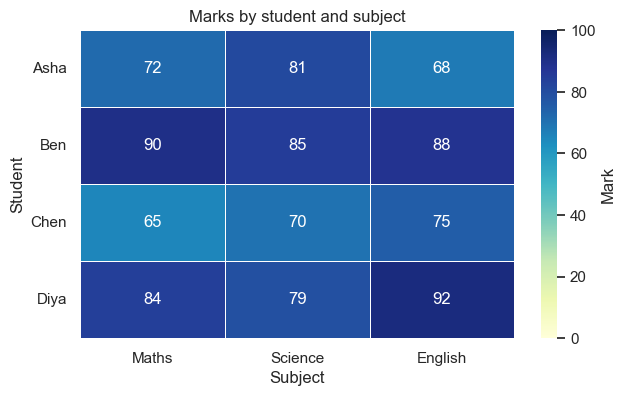

In [62]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    marks, annot=True, fmt="d", cmap="YlGnBu", vmin=0, vmax=100,
    xticklabels=subjects, yticklabels=students,
    linewidths=0.5, cbar_kws={"label": "Mark"}, ax=ax,
)
ax.set(title="Marks by student and subject", xlabel="Subject", ylabel="Student")
ax.tick_params(axis="y", rotation=0)
plt.show()


### 26. Correlation heatmap (optional)
NumPy calculates; Seaborn displays. Correlation describes linear association, not causation.


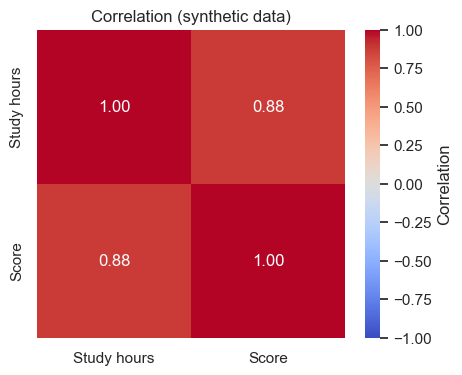

In [63]:
measurements = np.column_stack([study_hours, scores])
correlation = np.corrcoef(measurements, rowvar=False)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    correlation, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
    center=0, square=True, xticklabels=["Study hours", "Score"],
    yticklabels=["Study hours", "Score"], cbar_kws={"label": "Correlation"}, ax=ax,
)
ax.set_title("Correlation (synthetic data)")
plt.show()


### 27. Figure-level Seaborn functions (optional)
`scatterplot` accepts an existing `ax`. `relplot` creates its own figure and can split data into panels.


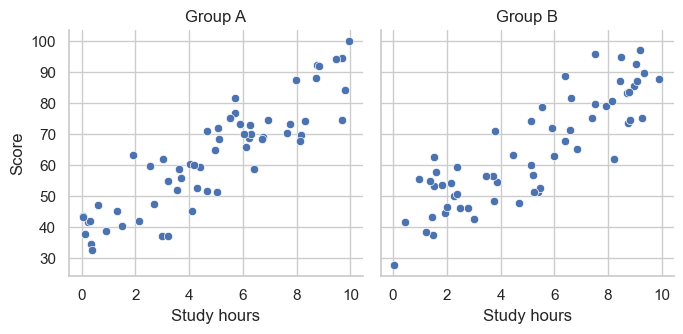

In [64]:
g = sns.relplot(x=study_hours, y=scores, col=groups, kind="scatter", height=3.5, aspect=1)
g.set_axis_labels("Study hours", "Score")
g.set_titles("{col_name}")
plt.show()


### 28. Save a plot
PNG stores pixels; SVG stores vector shapes. Save using the Figure object.


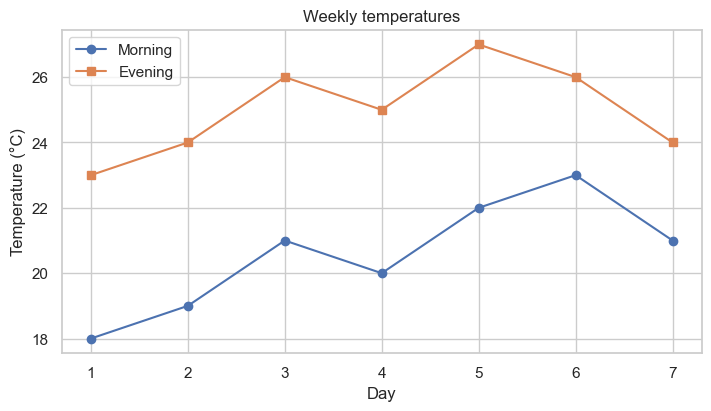

Saved in: /Users/oseekero/myCoolProjects/numpy_stuff/session_outputs


In [65]:
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.plot(days, morning, marker="o", label="Morning")
ax.plot(days, evening, marker="s", label="Evening")
ax.set(title="Weekly temperatures", xlabel="Day", ylabel="Temperature (°C)")
ax.legend()
fig.savefig(output_dir / "temperatures.png", dpi=150, bbox_inches="tight")
fig.savefig(output_dir / "temperatures.svg", bbox_inches="tight")
plt.show()
print("Saved in:", output_dir.resolve())


### Final challenge
Generate 30 days of readings for 3 sensors. Subtract each sensor’s mean with broadcasting. Plot the original readings as lines and the centred readings as a heatmap.


In [66]:
# Starter data: rows = days, columns = sensors
rng = np.random.default_rng(12)
sensor_readings = rng.normal(loc=[20, 25, 30], scale=2, size=(30, 3))

# Your code here


## Exercise solutions
Open these after trying the exercises.


In [67]:
totals_by_student = marks.sum(axis=1)
selected_students = np.array(students)[marks.mean(axis=1) >= 80]
print("Totals:", totals_by_student)
print("Average >= 80:", selected_students)

student_centred = marks - marks.mean(axis=1, keepdims=True)
print("Centred within each student:\n", student_centred.round(2))


Totals: [221 263 210 255]
Average >= 80: ['Ben' 'Diya']
Centred within each student:
 [[-1.67  7.33 -5.67]
 [ 2.33 -2.67  0.33]
 [-5.    0.    5.  ]
 [-1.   -6.    7.  ]]


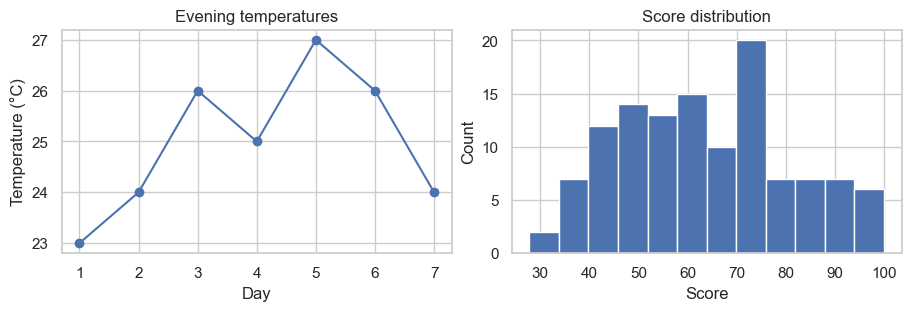

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
axes[0].plot(days, evening, marker="o")
axes[0].set(title="Evening temperatures", xlabel="Day", ylabel="Temperature (°C)")
axes[1].hist(scores, bins=12, edgecolor="white")
axes[1].set(title="Score distribution", xlabel="Score", ylabel="Count")
plt.show()


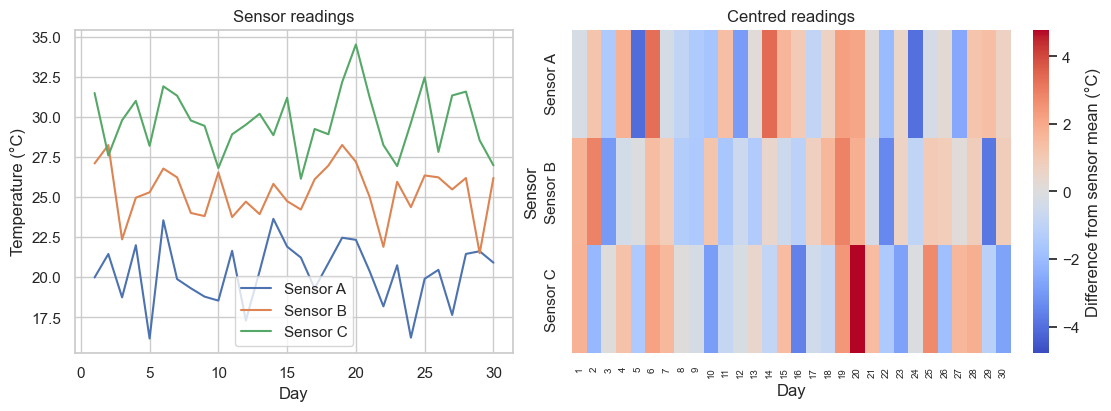

In [69]:
sensor_centred = sensor_readings - sensor_readings.mean(axis=0, keepdims=True)
sensor_days = np.arange(1, 31)
sensor_names = ["Sensor A", "Sensor B", "Sensor C"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for column, name in enumerate(sensor_names):
    axes[0].plot(sensor_days, sensor_readings[:, column], label=name)
axes[0].set(title="Sensor readings", xlabel="Day", ylabel="Temperature (°C)")
axes[0].legend()

limit = np.abs(sensor_centred).max()
sns.heatmap(
    sensor_centred.T, cmap="coolwarm", center=0, vmin=-limit, vmax=limit,
    xticklabels=sensor_days, yticklabels=sensor_names,
    cbar_kws={"label": "Difference from sensor mean (°C)"}, ax=axes[1],
)
axes[1].set(title="Centred readings", xlabel="Day", ylabel="Sensor")
axes[1].tick_params(axis="x", labelsize=7)
plt.show()


## References
[NumPy basics](https://numpy.org/doc/stable/user/absolute_beginners.html) · [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) · [Matplotlib guide](https://matplotlib.org/stable/users/explain/quick_start.html) · [Seaborn overview](https://seaborn.pydata.org/tutorial/function_overview.html)
